***DATA PREPARATION***

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


PATH = "/home/suhas/projects/Mini_Project/data/cropped"

X, y = [], []

for sub_folder in sorted(os.listdir(PATH)):
    sub_path = os.path.join(PATH, sub_folder)

    if not os.path.isdir(sub_path):
        continue
    if not sub_folder.startswith("yaleB"):
        continue

    sub_id =int(sub_folder.replace("yaleB",""))

    for name in sorted(os.listdir(sub_path)):
        if not name.endswith(".pgm"):
            continue

        img_path = os.path.join(sub_path,name)
        img = Image.open(img_path).convert("L")

        X.append(np.array(img).flatten())
        y.append(sub_id)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"Dataset shape : {X.shape}")
print(f"Labels shape  : {y.shape}")
print(f"Subjects found: {np.unique(y)}")
counts = np.bincount(y)

for label in np.unique(y):
    print(f"Subject {label}: {counts[label]} images")



Dataset shape : (16380, 32256)
Labels shape  : (16380,)
Subjects found: [11 12 13 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39]
Subject 11: 585 images
Subject 12: 585 images
Subject 13: 585 images
Subject 15: 585 images
Subject 16: 585 images
Subject 17: 585 images
Subject 18: 585 images
Subject 19: 585 images
Subject 20: 585 images
Subject 21: 585 images
Subject 22: 585 images
Subject 23: 585 images
Subject 24: 585 images
Subject 25: 585 images
Subject 26: 585 images
Subject 27: 585 images
Subject 28: 585 images
Subject 29: 585 images
Subject 30: 585 images
Subject 31: 585 images
Subject 32: 585 images
Subject 33: 585 images
Subject 34: 585 images
Subject 35: 585 images
Subject 36: 585 images
Subject 37: 585 images
Subject 38: 585 images
Subject 39: 585 images


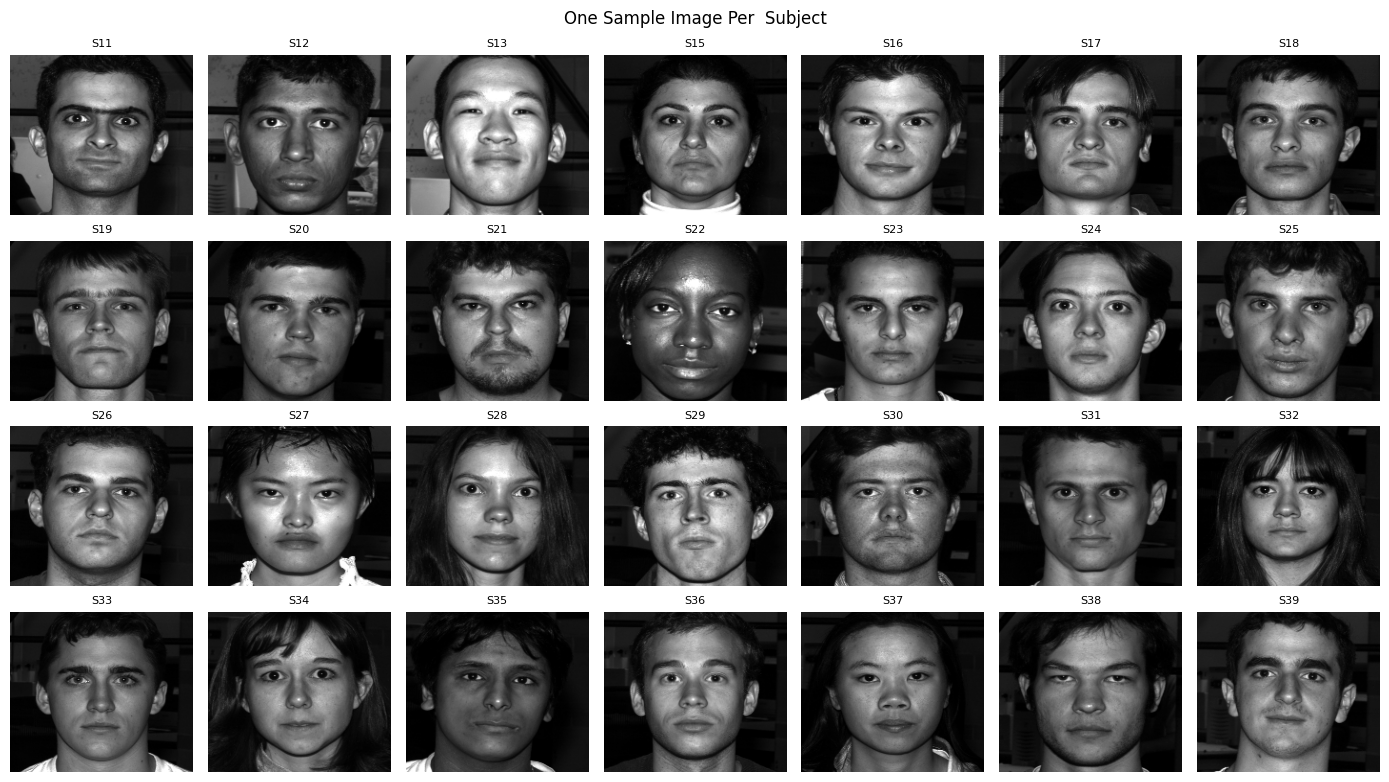

In [3]:
#Sample images for each subject
IMAGE_H, IMAGE_W = 168, 192   

fig, axes = plt.subplots(4, 7, figsize=(14, 8))
subjects = np.unique(y)

for idx, subject in enumerate(subjects[:28]):
    ax = axes[idx // 7, idx % 7]
    first_idx = np.where(y == subject)[0][0]
    ax.imshow(X[first_idx].reshape(IMAGE_H, IMAGE_W), cmap='gray')
    ax.set_title(f"S{subject:02d}", fontsize=8)
    ax.axis('off')

plt.suptitle("One Sample Image Per  Subject")
plt.tight_layout()
plt.show()

In [4]:
#Normalization from [0,255] to [0,1]

X = X / 255.0

#Stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y    
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (13104, 32256), Test: (3276, 32256)


***Dimensionality Reduction***

In [5]:
pca = PCA(n_components=450)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

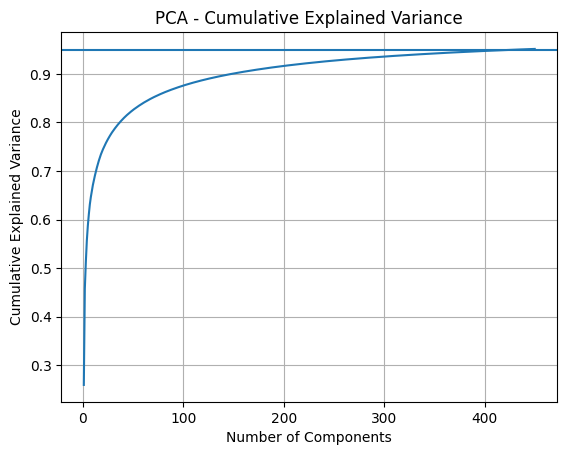

Using 450 components:
Total variance captured: 95.15%
Interpretation: Sufficient components (≥95% variance captured).


In [6]:
# cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

# total variance for chosen components
total_var = cum_var[-1]

# plot
plt.figure()
plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid()

plt.show()

# print interpretation
print(f"Using {pca.n_components_} components:")
print(f"Total variance captured: {total_var*100:.2f}%")

if total_var >= 0.95:
    print("Interpretation: Sufficient components (≥95% variance captured).")
else:
    print("Interpretation: Most variance captured, but increasing components may improve performance.")

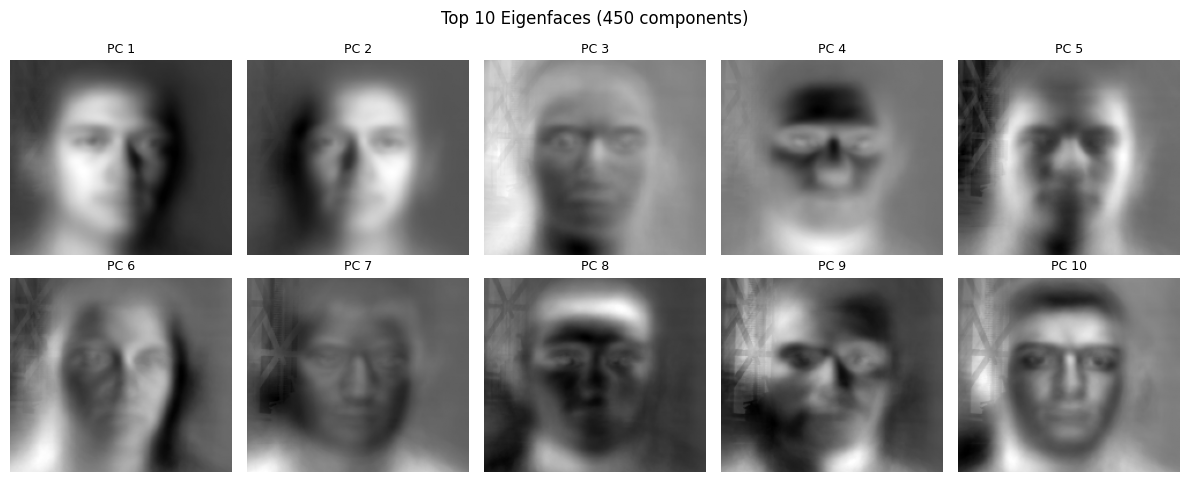

Eigenvalue 1: 274.5004
Eigenvalue 2: 209.3530
Eigenvalue 3: 57.7911
Eigenvalue 4: 47.1347
Eigenvalue 5: 32.5305
Eigenvalue 6: 24.9194
Eigenvalue 7: 21.5652
Eigenvalue 8: 15.8689
Eigenvalue 9: 13.1242
Eigenvalue 10: 12.7834


In [7]:
IMAGE_H, IMAGE_W = 168, 192
N_SHOW = 10

components = pca.components_   

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(N_SHOW):
    ax = axes[i // 5, i % 5]
    
    eigenface = components[i].reshape(IMAGE_H, IMAGE_W)
    eigenface = (eigenface - eigenface.min()) / (eigenface.max() - eigenface.min())
    
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f"PC {i+1}", fontsize=9)
    ax.axis('off')

plt.suptitle("Top 10 Eigenfaces (450 components)", fontsize=12)
plt.tight_layout()
plt.show()

for i in range(10):
    print(f"Eigenvalue {i+1}: {pca.explained_variance_[i]:.4f}")

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


k_values = [1,3,5,7,9]

res = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca,y_train)

    y_pred = knn.predict(X_test_pca)
    acc = accuracy_score(y_test,y_pred)

    res[k] = (y_pred,acc)

    print(f"K={k} -> Accuracy={acc:.4f}")

best_k = max(res, key=lambda k: res[k][1])
y_pred_knn = res[best_k][0]
best_acc_knn = res[best_k][1]

print("\nBest K:", best_k)
print(f"Best KNN Accuracy: {best_acc_knn:.4f}")


K=1 -> Accuracy=0.8315
K=3 -> Accuracy=0.7955
K=5 -> Accuracy=0.7869
K=7 -> Accuracy=0.7869
K=9 -> Accuracy=0.7796

Best K: 1
Best KNN Accuracy: 0.8315


In [9]:
#Support Function

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

def evaluate_model(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap="viridis", annot=True, fmt="d", annot_kws={"size": 5})
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


In [10]:
from sklearn.svm import SVC

kernels = ['linear','rbf','poly']
svm_models = {}
svm_preds = {}

for kernel in kernels:
    model = SVC(kernel=kernel)
    model.fit(X_train_pca,y_train)

    y_pred = model.predict(X_test_pca)

    svm_models[kernel] = model
    svm_preds[kernel] = y_pred

    print(f"SVM ({kernel}) trained")

best_kernel = None
best_acc_svm = 0

for kernel in kernels:
    acc = accuracy_score(y_test, svm_preds[kernel])
    
    if acc > best_acc_svm:
        best_acc_svm = acc
        best_kernel = kernel

y_pred_svm = svm_preds[best_kernel]

print("\nBest SVM Kernel:", best_kernel)
print(f"Best SVM Accuracy: {best_acc_svm:.4f}")

SVM (linear) trained
SVM (rbf) trained
SVM (poly) trained

Best SVM Kernel: rbf
Best SVM Accuracy: 0.9106



=== SVM (linear) ===
Accuracy: 0.8840
              precision    recall  f1-score   support

          11       0.91      0.98      0.95       117
          12       0.95      0.97      0.96       117
          13       0.90      0.97      0.93       117
          15       0.90      0.88      0.89       117
          16       0.87      0.89      0.88       117
          17       0.76      0.80      0.78       117
          18       0.88      0.91      0.90       117
          19       0.80      0.87      0.83       117
          20       0.80      0.81      0.81       117
          21       0.85      0.85      0.85       117
          22       0.92      0.85      0.88       117
          23       0.91      0.89      0.90       117
          24       0.88      0.90      0.89       117
          25       0.81      0.81      0.81       117
          26       0.85      0.85      0.85       117
          27       0.92      0.94      0.93       117
          28       0.93      0.95      0.9

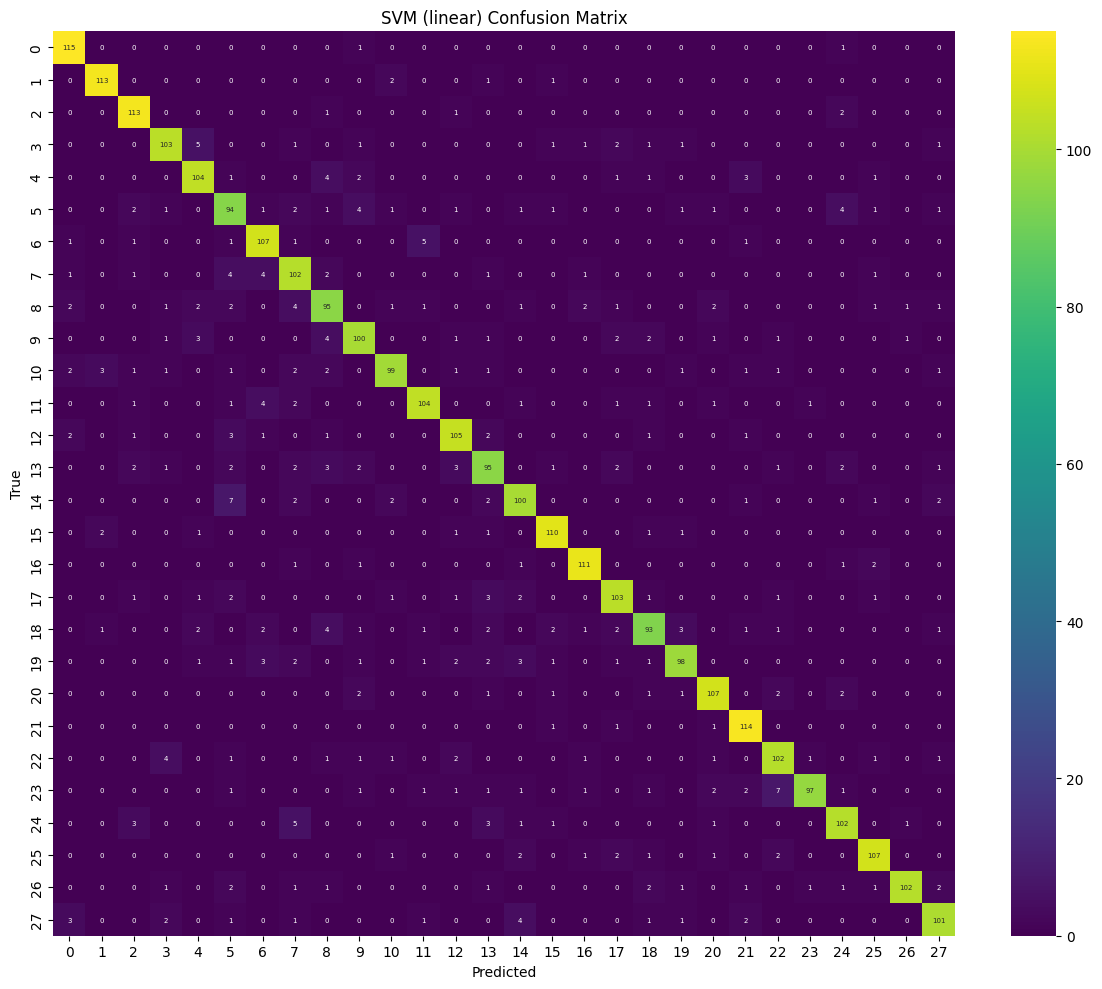


=== SVM (rbf) ===
Accuracy: 0.9106
              precision    recall  f1-score   support

          11       0.95      0.99      0.97       117
          12       0.98      0.97      0.97       117
          13       0.91      0.98      0.95       117
          15       0.97      0.84      0.90       117
          16       0.91      0.90      0.91       117
          17       0.91      0.91      0.91       117
          18       0.92      0.93      0.93       117
          19       0.95      0.91      0.93       117
          20       0.81      0.82      0.82       117
          21       0.95      0.85      0.90       117
          22       0.96      0.93      0.94       117
          23       0.98      0.87      0.92       117
          24       0.95      0.93      0.94       117
          25       0.97      0.84      0.90       117
          26       0.99      0.93      0.96       117
          27       0.95      0.92      0.94       117
          28       0.95      0.91      0.93  

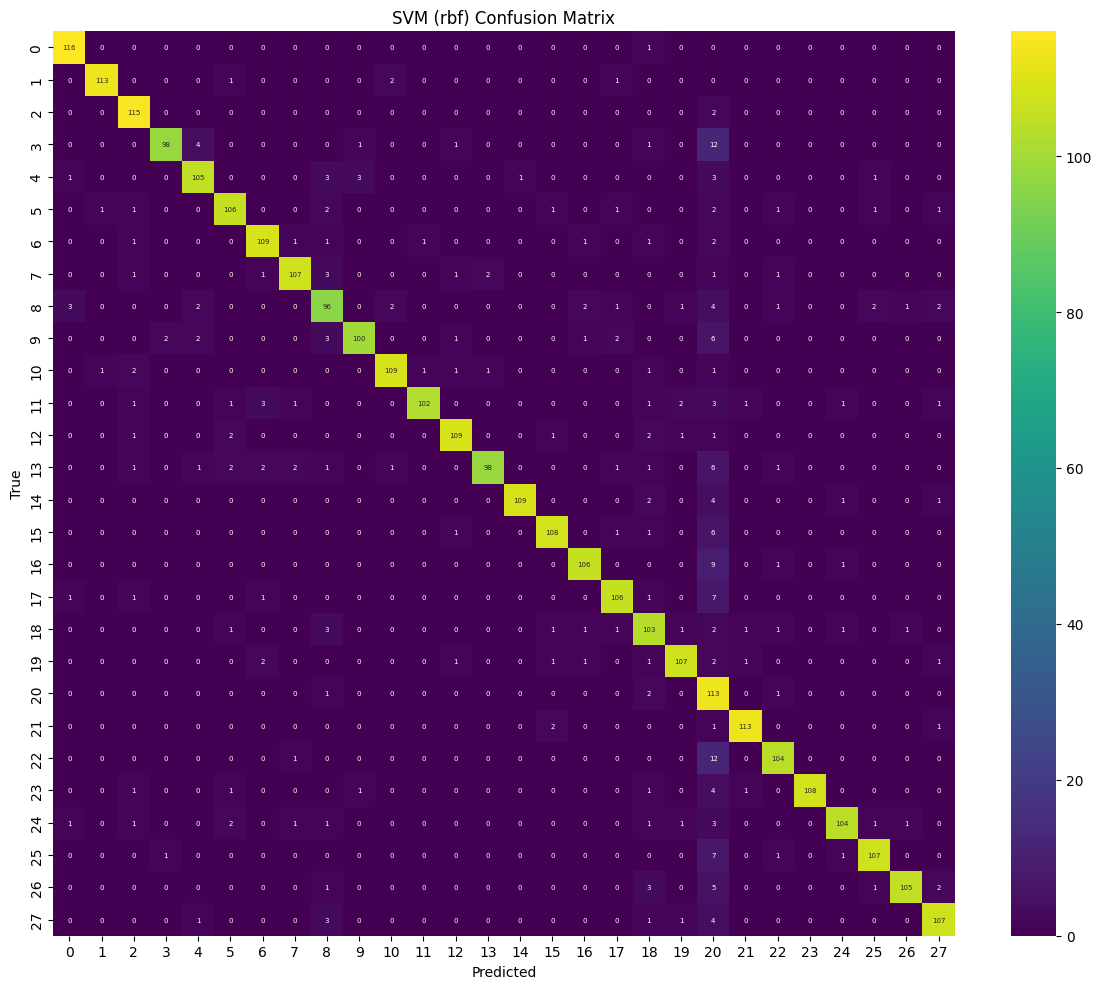


=== SVM (poly) ===
Accuracy: 0.8394
              precision    recall  f1-score   support

          11       0.89      0.93      0.91       117
          12       0.95      0.96      0.95       117
          13       0.95      0.92      0.94       117
          15       0.95      0.74      0.83       117
          16       0.90      0.83      0.86       117
          17       0.83      0.78      0.81       117
          18       0.74      0.91      0.82       117
          19       0.70      0.84      0.76       117
          20       0.77      0.75      0.76       117
          21       0.97      0.74      0.83       117
          22       0.96      0.92      0.94       117
          23       0.98      0.78      0.87       117
          24       0.98      0.86      0.92       117
          25       0.94      0.72      0.82       117
          26       0.99      0.79      0.88       117
          27       0.96      0.83      0.89       117
          28       0.93      0.85      0.89 

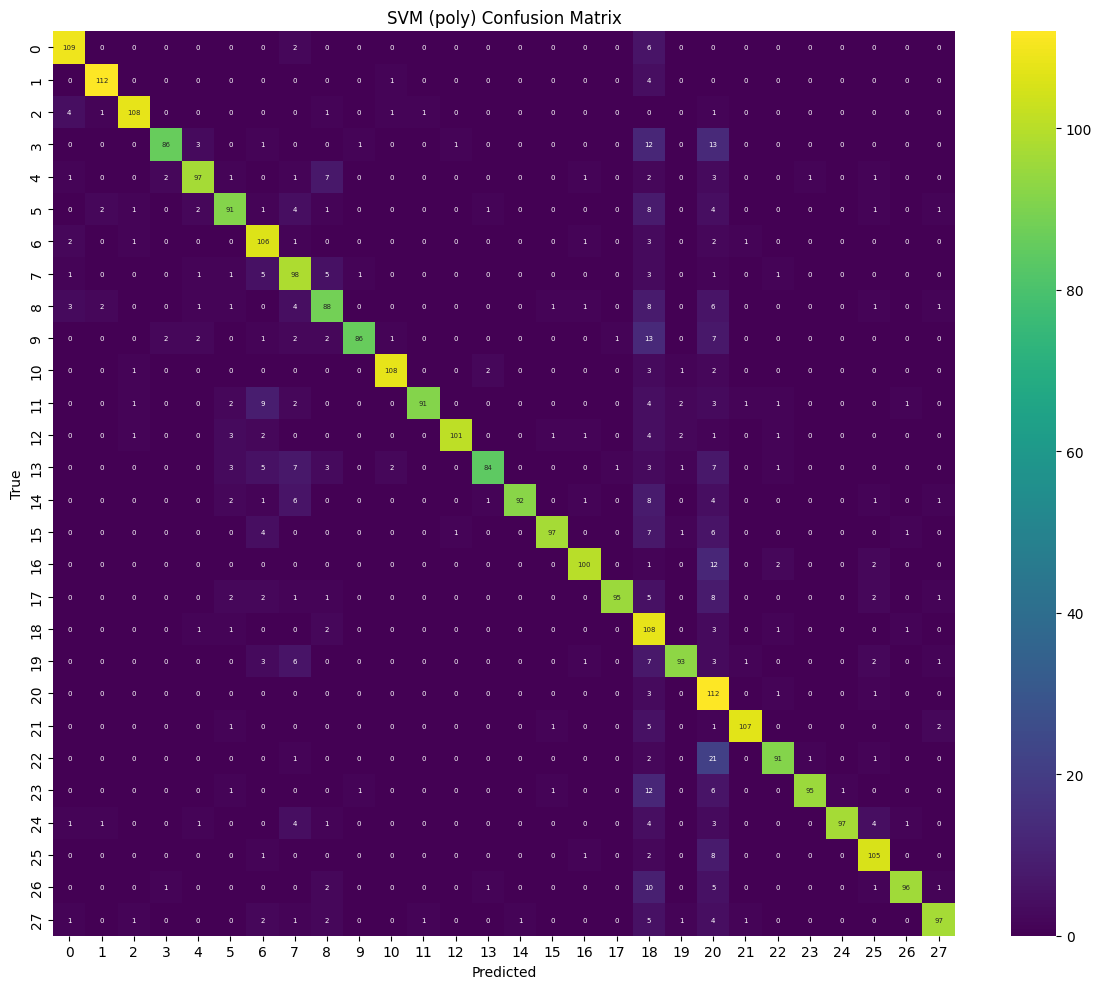

In [11]:
for kernel in kernels:
    evaluate_model(y_test, svm_preds[kernel], f"SVM ({kernel})")

In [12]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_pca, y_train)

y_pred_nb = nb.predict(X_test_pca)


=== Naive Bayes ===
Accuracy: 0.5937
              precision    recall  f1-score   support

          11       0.96      0.65      0.78       117
          12       0.98      0.85      0.91       117
          13       0.29      0.83      0.43       117
          15       0.85      0.52      0.65       117
          16       0.85      0.61      0.71       117
          17       0.65      0.37      0.47       117
          18       0.79      0.64      0.71       117
          19       0.46      0.51      0.48       117
          20       0.31      0.52      0.39       117
          21       0.89      0.53      0.66       117
          22       0.70      0.63      0.66       117
          23       0.51      0.47      0.49       117
          24       0.77      0.56      0.65       117
          25       0.76      0.46      0.57       117
          26       0.76      0.57      0.65       117
          27       0.77      0.71      0.74       117
          28       0.48      0.74      0.59

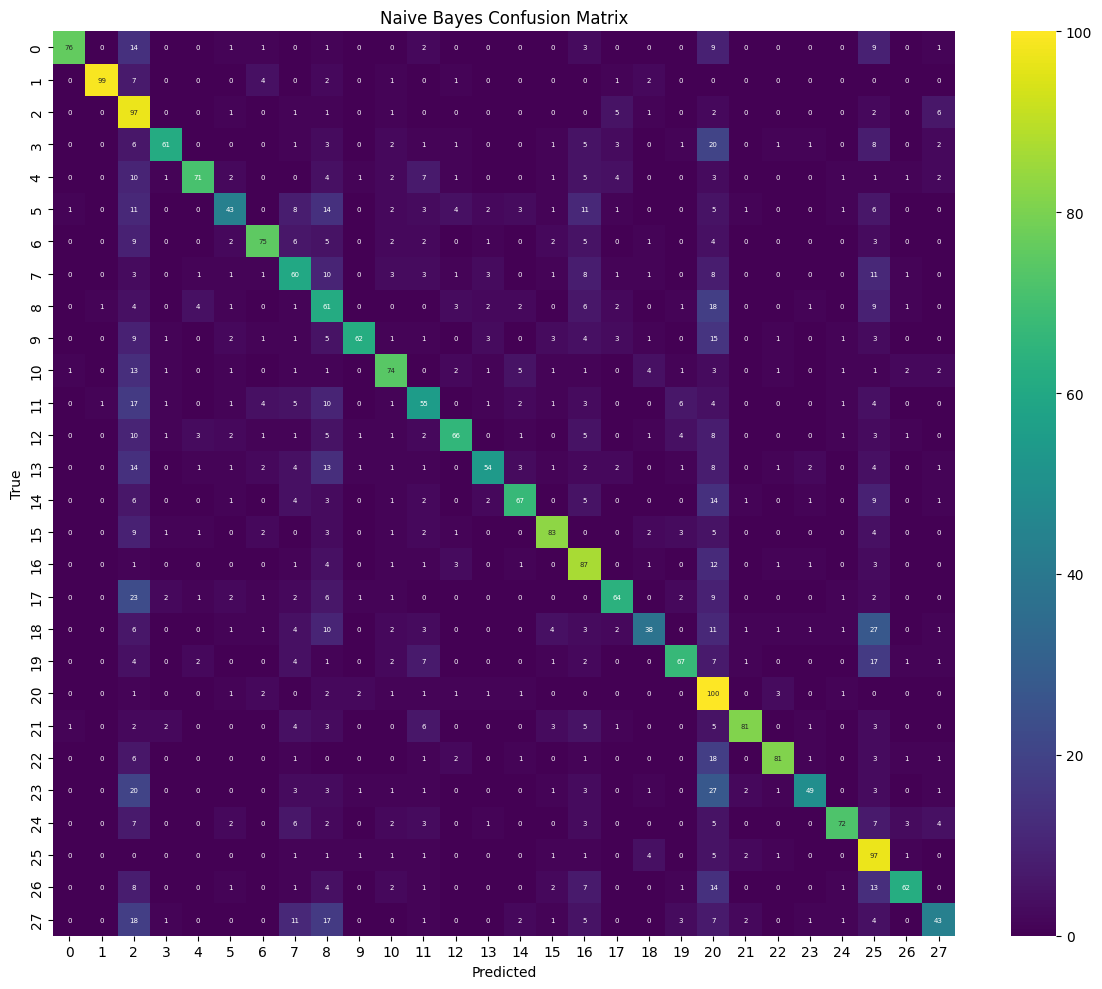

In [13]:
evaluate_model(y_test, y_pred_nb, "Naive Bayes")


Running for n = 100

Running for n = 150

Running for n = 300

Running for n = 450


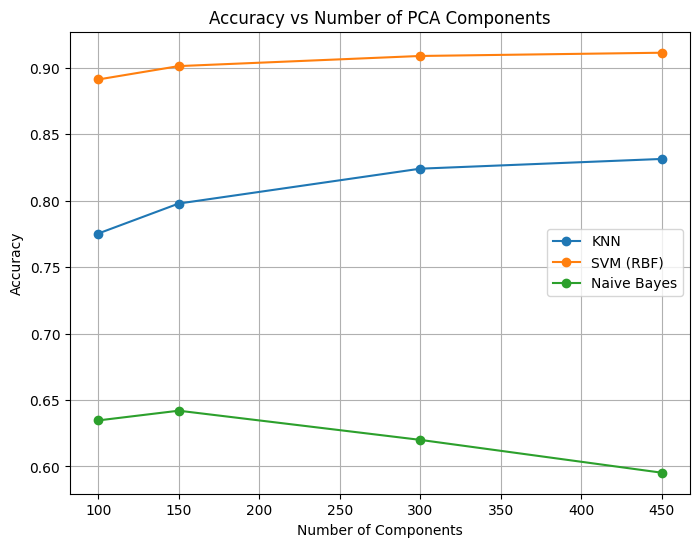

In [14]:
from sklearn.decomposition import IncrementalPCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# reduce memory
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

components_list = [100, 150, 300, 450]

knn_acc = []
svm_acc = []
nb_acc = []

for n in components_list:
    print(f"\nRunning for n = {n}")
    
    # memory-efficient PCA
    pca = IncrementalPCA(n_components=n, batch_size=500)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # KNN (best k=1)
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_pca, y_train)
    knn_acc.append(accuracy_score(y_test, knn.predict(X_test_pca)))
    
    # SVM (best = RBF)
    svm = SVC(kernel='rbf')
    svm.fit(X_train_pca, y_train)
    svm_acc.append(accuracy_score(y_test, svm.predict(X_test_pca)))
    
    # Naive Bayes
    nb = GaussianNB()
    nb.fit(X_train_pca, y_train)
    nb_acc.append(accuracy_score(y_test, nb.predict(X_test_pca)))
    
    # free memory
    del X_train_pca, X_test_pca, pca, knn, svm, nb

# Plot
plt.figure(figsize=(8, 6))
plt.plot(components_list, knn_acc, marker='o', label='KNN')
plt.plot(components_list, svm_acc, marker='o', label='SVM (RBF)')
plt.plot(components_list, nb_acc, marker='o', label='Naive Bayes')

plt.xlabel("Number of Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of PCA Components")
plt.legend()
plt.grid()
plt.show()

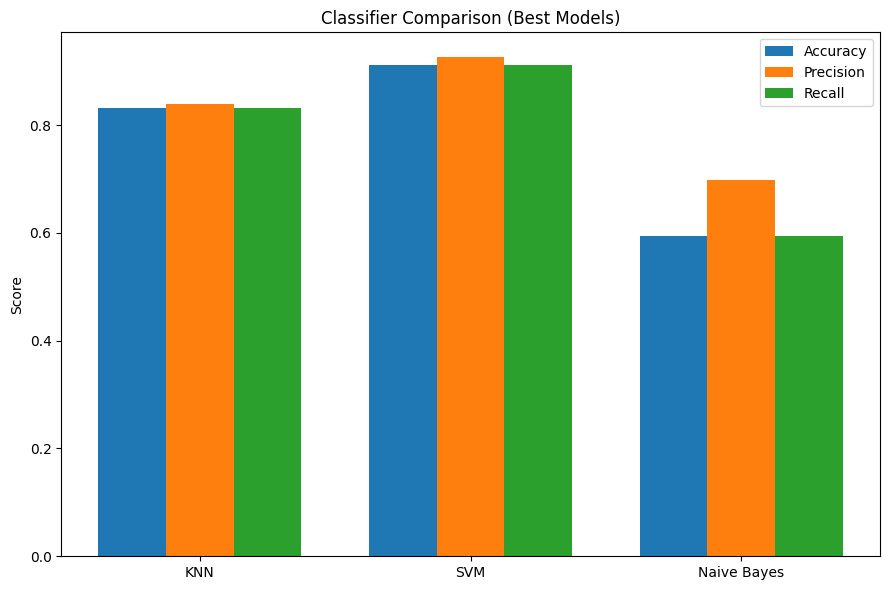

In [15]:
from sklearn.metrics import precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

models = {
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb
}

accuracy = []
precision = []
recall = []

for pred in models.values():
    accuracy.append(accuracy_score(y_test, pred))
    precision.append(precision_score(y_test, pred, average='macro'))
    recall.append(recall_score(y_test, pred, average='macro'))

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 6))

plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, recall, width, label='Recall')

plt.xticks(x, list(models.keys()))
plt.ylabel("Score")
plt.title("Classifier Comparison (Best Models)")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
best_model = None
best_acc = 0

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    
    if acc > best_acc:
        best_acc = acc
        best_model = name

print("\nBest Overall Model:", best_model)
print(f"Best Accuracy: {best_acc:.4f}")


Best Overall Model: SVM
Best Accuracy: 0.9106


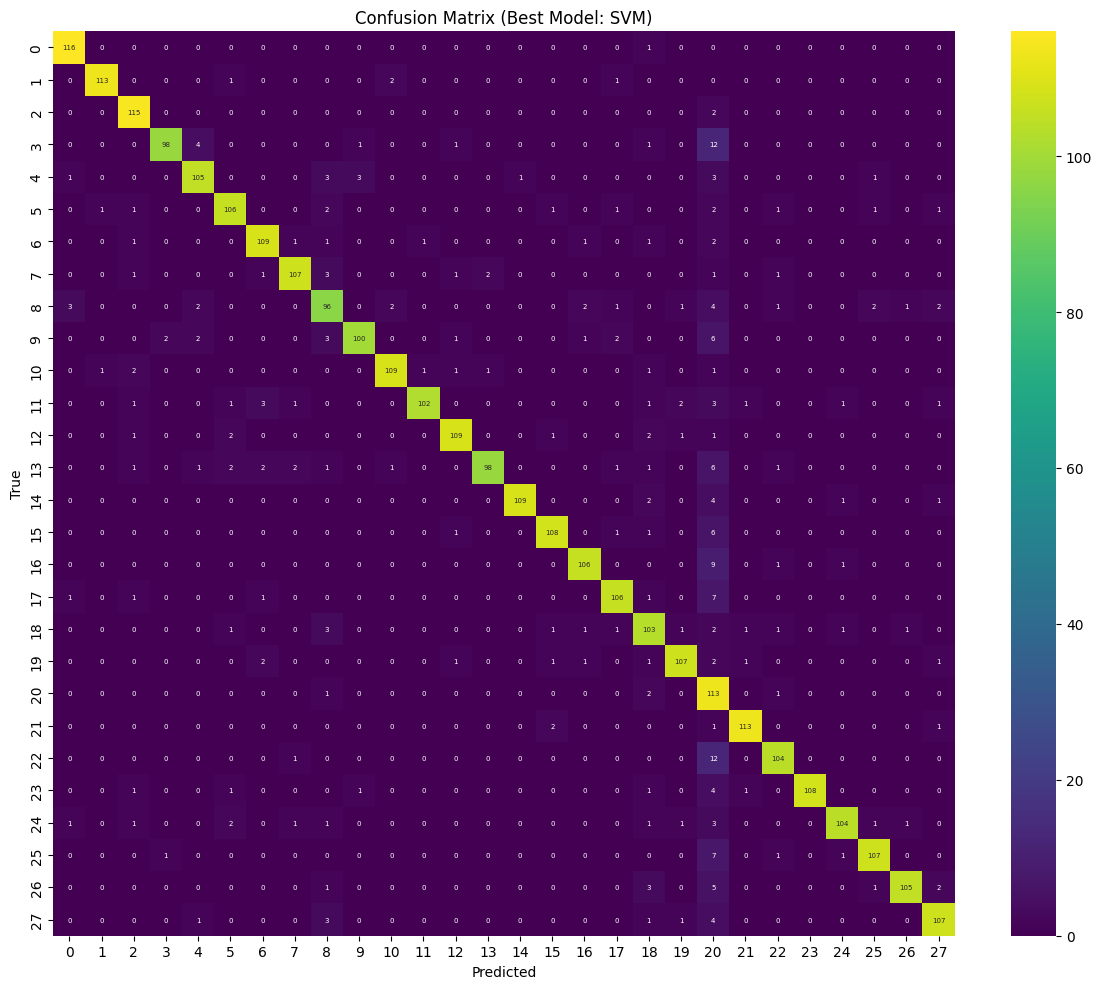

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_best = models[best_model]

cm = confusion_matrix(y_test, y_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", annot_kws={"size": 5})

plt.title(f"Confusion Matrix (Best Model: {best_model})")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()



In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pca = PCA(n_components=450)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

param_grid = {
    'C': [5, 10, 20, 50],
    'gamma': ['scale',0.005, 0.01],
    'kernel': ['rbf']
}

svm = SVC()

grid = GridSearchCV(svm, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_pca, y_train)

best_svm = grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_pca)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'C': 20, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9297924297924297


***Logistic Regression***

In [19]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter = 1000,
    solver = 'lbfgs',
    C = 10,
    random_state = 16
)

logreg.fit(X_train_pca,y_train)

y_pred_logreg = logreg.predict(X_test_pca)





In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Logistic Regression Accuracy: 85.93%


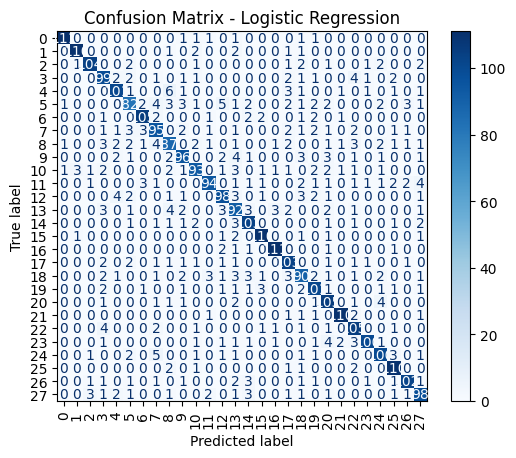

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

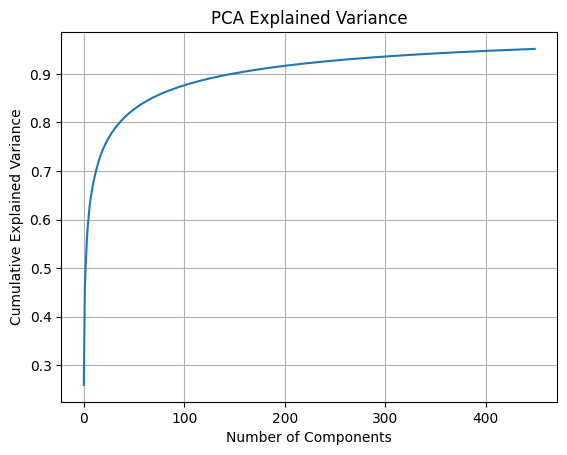

In [22]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

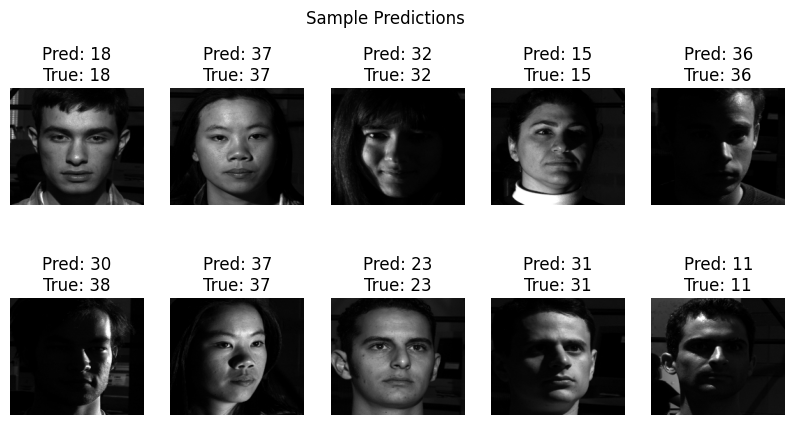

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(168,192), cmap='gray')
    ax.set_title(f"Pred: {y_pred_logreg[i]}\nTrue: {y_test[i]}")
    ax.axis('off')

plt.suptitle("Sample Predictions")
plt.show()

In [25]:
svm_best = SVC(
    C=20,
    kernel='rbf',
    gamma='scale'
)

svm_best.fit(X_train_pca,y_train)

y_pred_best_svm = svm_best.predict(X_test_pca)

best_svm_acc = accuracy_score(y_test,y_pred_best_svm)

print(f"Test Accuracy (SVM): {best_svm_acc * 100:.4f}%")

Test Accuracy (SVM): 94.5971%
